In [1]:
# %pip install seaborn

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# darkgrid, whitegrid, dark, white, ticks
# https://seaborn.pydata.org/tutorial/color_palettes.html
sns.set_style('whitegrid') # clean background
sns.set_palette('viridis') # color
plt.rcParams['figure.figsize'] = (10,6)

In [4]:
# Synthetic data for Mumbai West (realistic prices & areas)
np.random.seed(42)  # For reproducible results

locations = ['Andheri West', 'Bandra West', 'Juhu', 'Santacruz West', 'Khar West', 'Bandra East', 'Versova']

data = {
    'BHK': np.random.choice([1, 2, 3, 4], 800, p=[0.15, 0.45, 0.3, 0.1]),
    'Locality': np.random.choice(locations, 800),
    'Area_sqft': np.random.normal(1100, 350, 800).astype(int).clip(600, 2500),
    'Price_Lakhs': np.random.normal(450, 280, 800).astype(int).clip(100, 3000),
    'Status': np.random.choice(['Ready to Move', 'Under Construction'], 800),
    'Age': np.random.choice(['0-1 Year', '1-5 Years', '5-10 Years', '10+ Years'], 800)
}

df = pd.DataFrame(data)

# Make prices realistic (premium areas cost more)
premium = ['Bandra West', 'Juhu', 'Khar West']
df.loc[df['Locality'].isin(premium), 'Price_Lakhs'] += 200
df['Price_Lakhs'] = (df['Price_Lakhs'] + (df['Area_sqft'] * 0.4) + (df['BHK'] * 80)).astype(int).clip(100, 3000)
df.to_csv('mumbai_west_housing.csv', index=False)
print(df.head())  # Peek at first 5 rows

   BHK        Locality  Area_sqft  Price_Lakhs              Status         Age
0    2         Versova       1231         1176       Ready to Move   1-5 Years
1    4     Bandra West        834         1482       Ready to Move  5-10 Years
2    3    Andheri West        624         1121  Under Construction  5-10 Years
3    2  Santacruz West        989         1757       Ready to Move  5-10 Years
4    2         Versova        840          596       Ready to Move  5-10 Years


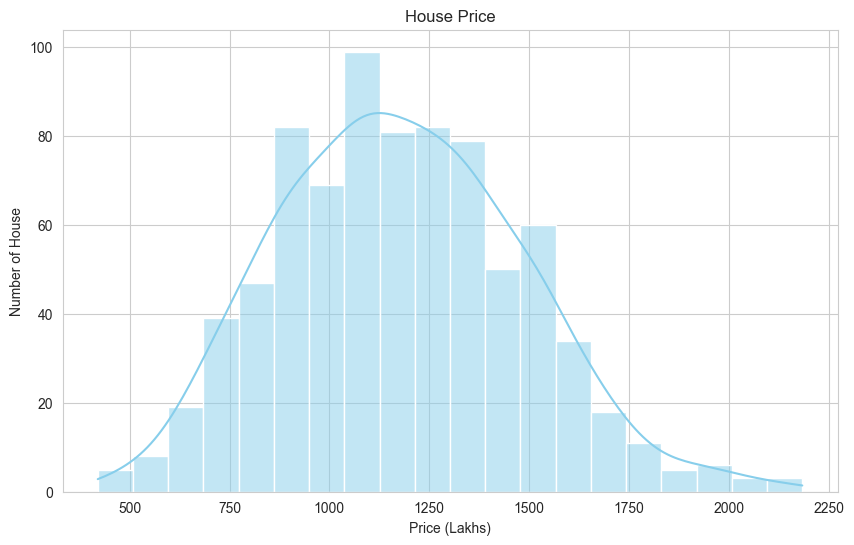

In [5]:
sns.histplot(
    data=df,
    x="Price_Lakhs",
    bins=20,
    color="skyblue",
    kde=True    
)
plt.title("House Price")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of House")
plt.show()

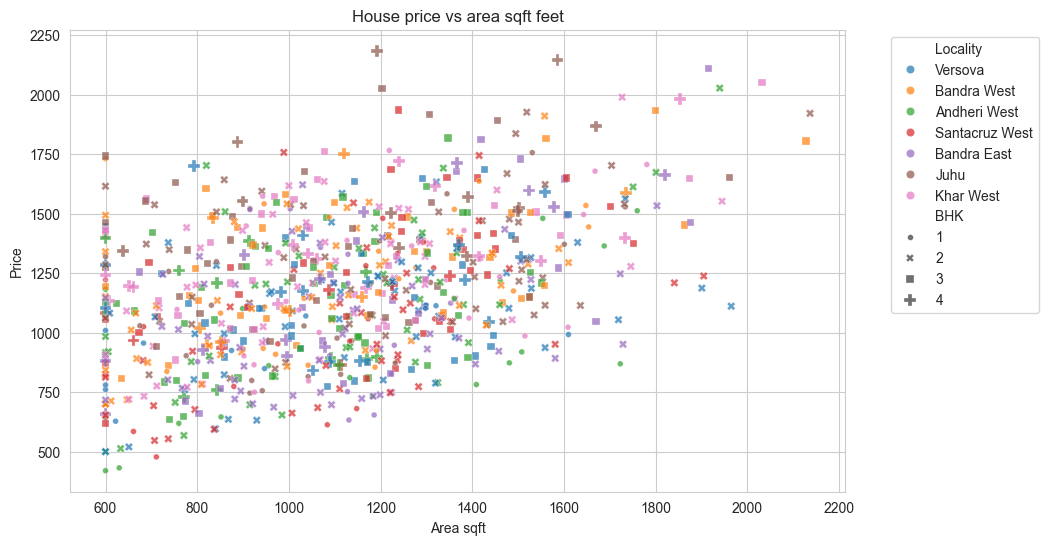

In [6]:
sns.scatterplot(
    data=df,
    x = 'Area_sqft',
    y = 'Price_Lakhs',
    hue = 'Locality',
    style= 'BHK',
    size = 'BHK',
    palette = 'tab10',
    alpha=0.7
)
plt.title("House price vs area sqft feet")
plt.xlabel("Area sqft")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.show()

In [7]:
df.head()

,BHK,Locality,Area_sqft,Price_Lakhs,Status,Age
0,2,Versova,1231,1176,Ready to Move,1-5 Years
1,4,Bandra West,834,1482,Ready to Move,5-10 Years
2,3,Andheri West,624,1121,Under Construction,5-10 Years
3,2,Santacruz West,989,1757,Ready to Move,5-10 Years
4,2,Versova,840,596,Ready to Move,5-10 Years


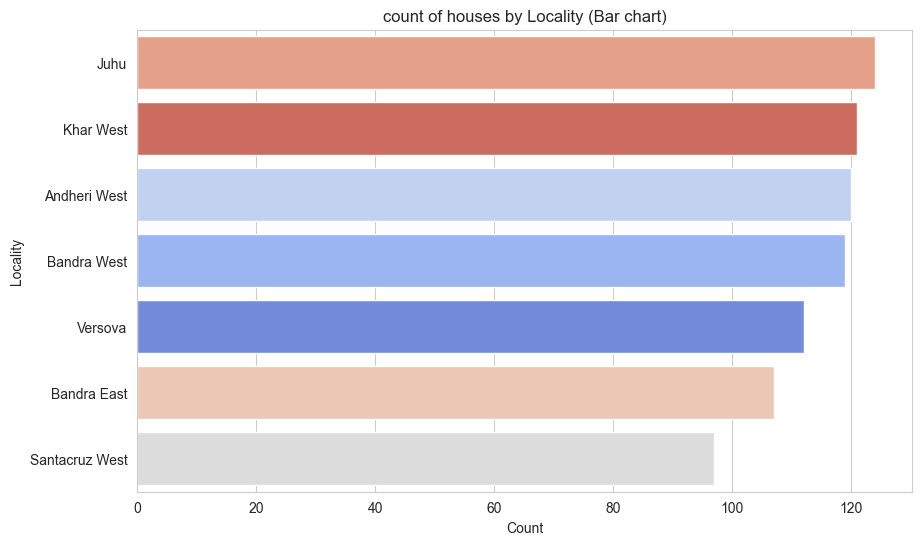

In [8]:
# count of houses by Locality (Bar chart)
sns.countplot(
    data=df,
    y='Locality',
    order=df['Locality'].value_counts().index,
    palette = 'coolwarm',
    hue='Locality'   
)
plt.title("count of houses by Locality (Bar chart)")
plt.xlabel('Count')
plt.ylabel('Locality')
plt.show()